In [45]:
import pandas as pd


In [46]:
df_prop=pd.read_csv("../data/Raw/properties_2016.csv")
df_train=pd.read_csv("../data/Raw/train_2016_v2.csv")
df_prop.tail()

C:\Users\DELL\AppData\Local\Temp\ipykernel_14472\3406481020.py:1: DtypeWarning: Columns (22,32,34,49,55) have mixed types. Specify dtype option on import or set low_memory=False.
  df_prop=pd.read_csv("../data/Raw/properties_2016.csv")


,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,numberofstories,fireplaceflag,structuretaxvaluedollarcnt,taxvaluedollarcnt,assessmentyear,landtaxvaluedollarcnt,taxamount,taxdelinquencyflag,taxdelinquencyyear,censustractandblock
2985212,168176230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2985213,14273630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2985214,168040630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2985215,168040830,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2985216,168040430,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:

df_train.head()

,parcelid,logerror,transactiondate
0,11016594,0.0276,2016-01-01
1,14366692,-0.1684,2016-01-01
2,12098116,-0.0040,2016-01-01
3,12643413,0.0218,2016-01-02
4,14432541,-0.0050,2016-01-02


In [48]:
print(f"shape of properties table:{df_prop.shape}")
print(f"shape of training table:{df_train.shape}")

shape of properties table:(2985217, 58)
shape of training table:(90275, 3)


In [49]:
df_merged=df_train.merge(df_prop,on="parcelid",how="left")
print(f"shape of merged table:{df_merged.shape}")

shape of merged table:(90275, 60)


In [50]:
df_merged.columns[:10]

Index(['parcelid', 'logerror', 'transactiondate', 'airconditioningtypeid',
       'architecturalstyletypeid', 'basementsqft', 'bathroomcnt', 'bedroomcnt',
       'buildingclasstypeid', 'buildingqualitytypeid'],
      dtype='object')

In [51]:
import numpy as np
from sklearn.metrics import pairwise
mean_lat=np.mean(df_merged["latitude"])
mean_long=np.mean(df_merged["longitude"])
df_merged["distance_from_mean"]=pairwise.haversine_distances(np.radians(df_merged[["latitude","longitude"]]),np.radians([[mean_lat,mean_long]])) * 6371000/1000
print(df_merged["distance_from_mean"].head())



0     5697.549893
1     4808.318639
2    10725.254840
3    13806.822092
4     8555.232314
Name: distance_from_mean, dtype: float64


In [52]:
df_merged.shape

(90275, 61)

In [53]:
df_merged = df_merged[
    [
        "bathroomcnt",
        "bedroomcnt",
        "calculatedfinishedsquarefeet",
        "latitude",
        "longitude",
        "distance_from_mean",
        "taxvaluedollarcnt"
        
    ]
]

In [54]:
features = [
    "bathroomcnt",
    "bedroomcnt",
    "calculatedfinishedsquarefeet",
    "latitude",
    "longitude",
    "taxvaluedollarcnt",
    "distance_from_mean"
    
    
]

df_merged[features].isnull().sum()

bathroomcnt                       0
bedroomcnt                        0
calculatedfinishedsquarefeet    661
latitude                          0
longitude                         0
taxvaluedollarcnt                 1
distance_from_mean                0
dtype: int64

In [55]:
df_clean = df_merged[features].dropna()

In [56]:
df_clean

,bathroomcnt,bedroomcnt,calculatedfinishedsquarefeet,latitude,longitude,taxvaluedollarcnt,distance_from_mean
0,2.0,3.0,1684.0,34280990.0,-118488536.0,360170.0,5697.549893
1,3.5,4.0,2263.0,33668120.0,-117677556.0,585529.0,4808.318639
2,3.0,2.0,2217.0,34136312.0,-118175032.0,119906.0,10725.254840
3,2.0,2.0,839.0,33755800.0,-118309000.0,244880.0,13806.822092
4,2.5,4.0,2283.0,33485643.0,-117700234.0,434551.0,8555.232314
...,...,...,...,...,...,...,...
90270,1.0,1.0,653.0,34203000.0,-118562000.0,191000.0,10102.721614
90271,3.0,3.0,2856.0,34198744.0,-118224849.0,161111.0,6886.034914
90272,2.0,4.0,2617.0,34075655.0,-118025537.0,38096.0,17024.515728
90273,2.0,2.0,1034.0,33963900.0,-118367000.0,165869.0,12238.981453


In [57]:
X = df_clean.drop("taxvaluedollarcnt", axis=1)
Y = df_clean["taxvaluedollarcnt"]

In [58]:
X.shape,Y.shape

((89613, 6), (89613,))

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=10)

In [61]:
print(f"Shape of test data: {X.shape},{Y_test.shape}")
print(f"Shape of train data: {X_train.shape},{Y_train.shape}")

Shape of test data: (89613, 6),(17923,)
Shape of train data: (71690, 6),(71690,)


In [62]:
X_train_coords = X_train[['latitude', 'longitude']].copy()
X_test_coords  = X_test[['latitude', 'longitude']].copy()

In [63]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=20,random_state=42)
kmeans.fit(X_train_coords)
X_train["location_cluster"]=kmeans.predict(X_train_coords)
X_test["location_cluster"]=kmeans.predict(X_test_coords)

In [64]:
X_train_coords['latitude'] = X_train_coords['latitude'] / 1e6
X_train_coords['longitude'] = X_train_coords['longitude'] / 1e6

X_test_coords['latitude'] = X_test_coords['latitude'] / 1e6
X_test_coords['longitude'] = X_test_coords['longitude'] / 1e6

In [65]:
import numpy as np

X_train_coords_rad = np.radians(X_train_coords)
X_test_coords_rad  = np.radians(X_test_coords)

In [66]:
from sklearn.neighbors import NearestNeighbors
knn=NearestNeighbors(n_neighbors=50, metric='haversine')
knn.fit(X_train_coords_rad)

,n_neighbors,50
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'haversine'
,p,2
,metric_params,None
,n_jobs,None


In [67]:
distances_train, indices_train = knn.kneighbors(X_train_coords_rad)
distances_test,indices_test=knn.kneighbors(X_test_coords_rad)

In [68]:
indices_train=indices_train[:,1:]
distances_train=distances_train[:,1:]
weight_train=1/(distances_train+1e-5)
weight_test=1/(distances_test+1e-5)

In [69]:
WeightedavgNeighborPrice_train=(Y_train.values[indices_train]*weight_train).sum(axis=1)/weight_train.sum(axis=1)
WeightedavgNeighborPrice_test=(Y_train.values[indices_test]*weight_test).sum(axis=1)/weight_test.sum(axis=1)

In [70]:
X_train["weighted_avg_neighbor_price"]=WeightedavgNeighborPrice_train
X_test["weighted_avg_neighbor_price"]=WeightedavgNeighborPrice_test

In [71]:
from sklearn.linear_model import LinearRegression

In [72]:
lr=LinearRegression()
lr.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [73]:
Y_pred=lr.predict(X_test)

In [74]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [75]:
mse=mean_squared_error(Y_test,Y_pred)
mae=mean_absolute_error(Y_test,Y_pred)
r2=r2_score(Y_test,Y_pred)

In [76]:
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")


Mean Absolute Error: 198552.78122876893
Mean Squared Error: 165061833363.16293
R2 Score: 0.4917075685228812


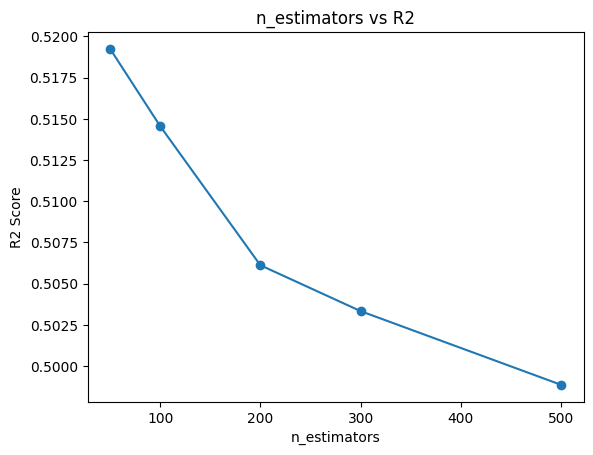

In [77]:
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

n_values = [50, 100, 200, 300, 500]
r2_scores = []

for n in n_values:
    model = XGBRegressor(
        n_estimators=n,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(Y_test, y_pred)
    r2_scores.append(r2)

plt.plot(n_values, r2_scores, marker='o')
plt.xlabel("n_estimators")
plt.ylabel("R2 Score")
plt.title("n_estimators vs R2")
plt.show()

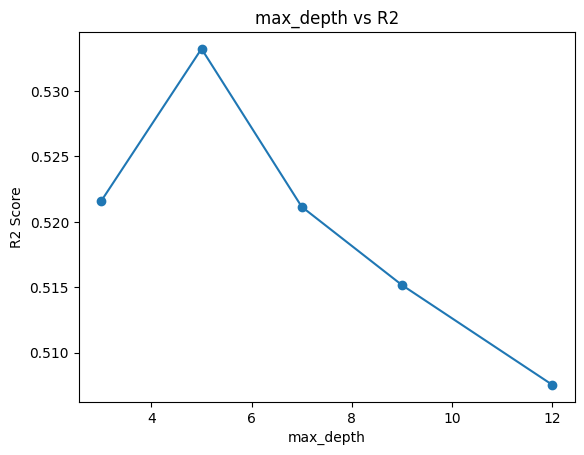

In [78]:
depth_values = [3, 5, 7, 9, 12]
r2_scores = []

for d in depth_values:
    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=d,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    
    r2_scores.append(r2_score(Y_test, y_pred))

plt.plot(depth_values, r2_scores, marker='o')
plt.xlabel("max_depth")
plt.ylabel("R2 Score")
plt.title("max_depth vs R2")
plt.show()

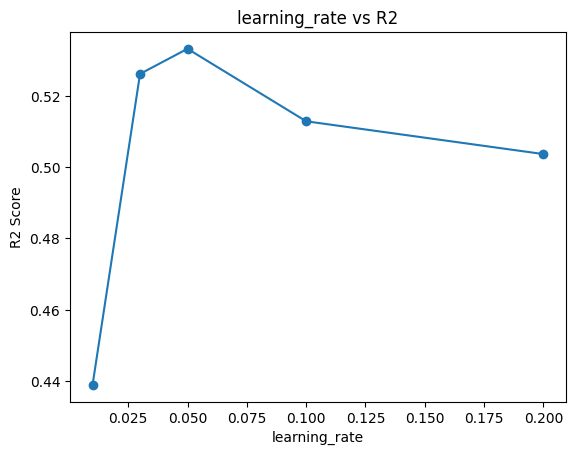

In [79]:
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

lr_values = [0.01, 0.03, 0.05, 0.1, 0.2]
r2_scores = []

for lr in lr_values:
    model = XGBRegressor(
        n_estimators=100,      
        max_depth=5,           
        learning_rate=lr,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(Y_test, y_pred)
    r2_scores.append(r2)

# Plot
plt.plot(lr_values, r2_scores, marker='o')
plt.xlabel("learning_rate")
plt.ylabel("R2 Score")
plt.title("learning_rate vs R2")
plt.show()

In [80]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, Y_train)
y_pred=model.predict(X_test)

In [81]:
mse=mean_squared_error(Y_test,y_pred)
mae=mean_absolute_error(Y_test,y_pred)
r2=r2_score(Y_test,y_pred)

In [82]:
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")


Mean Absolute Error: 178555.10077440648
Mean Squared Error: 151577022452.552
R2 Score: 0.5332327787190094


In [83]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=False).head(10)

weighted_avg_neighbor_price     0.370959
calculatedfinishedsquarefeet    0.213028
bathroomcnt                     0.187016
location_cluster                0.052466
latitude                        0.050742
longitude                       0.049748
distance_from_mean              0.045543
bedroomcnt                      0.030498
dtype: float32

In [84]:
X_train = X_train.drop(columns=['location_cluster'])
X_test  = X_test.drop(columns=['location_cluster'])

In [85]:
train_df = X_train.copy()
train_df["target"] = Y_train

test_df = X_test.copy()
test_df["target"] = Y_test

In [89]:
train_df.to_csv("../data/Processed/train_processed.csv", index=False)
test_df.to_csv("../data/Processed/test_processed.csv", index=False)

In [92]:
import osmnx as ox
place = "Los Angeles, California, USA"
tags = {"amenity": "school"}
schools = ox.features_from_place(place, tags)
print(schools.head())
schools.columns[:]

                                      geometry amenity  ele gnis:feature_id  \
element id                                                                    
node    358779466  POINT (-118.59272 34.24222)  school  279          238437   
        358779518  POINT (-118.20646 34.11029)  school  167          238488   
        358779550  POINT (-118.17202 34.08584)  school  158          238526   
        358779618  POINT (-118.34006 34.04309)  school   52          238557   
        358779821   POINT (-118.3073 34.25517)  school  446          238666   

                                          name  \
element id                                       
node    358779466          Aggeler High School   
        358779518     Aldama Elementary School   
        358779550            All Saints School   
        358779618  Alta Loma Elementary School   
        358779821   Apperson Elementary School   

                                              operator created_by addr:city  \
element id      

Index(['geometry', 'amenity', 'ele', 'gnis:feature_id', 'name', 'operator',
       'created_by', 'addr:city', 'addr:housenumber', 'addr:postcode',
       'addr:state', 'addr:street', 'education', 'wikidata', 'website',
       'wheelchair', 'note', 'fixme', 'phone', 'denomination', 'religion',
       'contact:phone', 'name:zh', 'toilets:wheelchair', 'alt_name',
       'operator:type', 'mascot', 'addr:suite', 'brand', 'brand:wikidata',
       'official_name', 'email', 'fax', 'addr:housename', 'source',
       'opening_hours', 'internet_access', 'short_name', 'toilets', 'grades',
       'school', 'operator:short', 'operator:wikidata', 'name:en', 'addr:unit',
       'name:etymology:wikidata', 'training', 'wikipedia', 'tourism', 'name_1',
       'operator:wikipedia', 'previously', 'not:brand:wikidata', 'source_ref',
       'not:operator:wikidata', 'start_date', 'building', 'building:levels',
       'height', 'lacounty:ain', 'lacounty:bld_id', 'check_date',
       'contact:facebook', 'contac

In [95]:
X_train["latitude"] = X_train["latitude"] / 1e6
X_train["longitude"] = X_train["longitude"] / 1e6

X_test["latitude"] = X_test["latitude"] / 1e6
X_test["longitude"] = X_test["longitude"] / 1e6

In [96]:
schools = schools[["geometry"]].copy()
schools = schools.dropna()

print(schools.shape)


(1089, 1)


In [97]:
import geopandas as gpd
X_train_geo = gpd.GeoDataFrame(
    X_train,
    geometry=gpd.points_from_xy(X_train["longitude"], X_train["latitude"])
)

In [98]:
X_train_geo.head()

,bathroomcnt,bedroomcnt,calculatedfinishedsquarefeet,latitude,longitude,distance_from_mean,weighted_avg_neighbor_price,geometry
85937,2.5,4.0,2266.0,33.833629,-117.859952,10910.789261,3.079688e+05,POINT (-117.85995 33.83363)
76520,3.0,5.0,2476.0,34.043079,-117.761973,4816.105006,2.299803e+05,POINT (-117.76197 34.04308)
18689,2.0,3.0,1671.0,34.196080,-118.561657,9233.552779,2.076915e+05,POINT (-118.56166 34.19608)
24107,2.0,4.0,2217.0,34.443771,-119.248500,6593.152222,3.991054e+05,POINT (-119.2485 34.44377)
42336,3.0,2.0,2121.0,33.614677,-117.924979,11052.312329,1.400227e+06,POINT (-117.92498 33.61468)


In [99]:
# Convert to projected CRS (meters)
X_train_geo = X_train_geo.to_crs(epsg=3857)
schools = schools.to_crs(epsg=3857)

ValueError: Cannot transform naive geometries.  Please set a crs on the object first.